In [1]:
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END

In [2]:
def model_name():
    return ChatOpenAI(model="gpt-5.6-luna")

In [3]:
class EssayState(BaseModel):
    essay: str

    reasoning_score: int = 0
    reasoning_feedback: str = ""

    depth_score: int = 0
    depth_feedback: str = ""

    language_score: int = 0
    language_feedback: str = ""

    final_score: float = 0.0
    summary: str = ""

In [4]:
model = model_name()

In [5]:
class EvalResult(BaseModel):
    score: int = Field(description="Score from 1 to 10")
    reason: str = Field(description="Short explanation")

structured_model = model.with_structured_output(EvalResult)

In [6]:
def chain_of_thought_evaluation(state: EssayState) -> dict:
    prompt = f"""
Evaluate the following essay for the quality of its reasoning
(logical thinking, strength of arguments, evidence, consistency).

Essay:
{state.essay}
"""
    result: EvalResult = structured_model.invoke(prompt)
    return {"reasoning_score": result.score, "reasoning_feedback": result.reason}




In [7]:
def depth_of_analysis_evaluation(state: EssayState) -> dict:
    prompt = f"""
Evaluate the following essay for depth of analysis
(multiple perspectives, cause-effect explanation, originality, examples).

Essay:
{state.essay}
"""
    result: EvalResult = structured_model.invoke(prompt)
    return {"depth_score": result.score, "depth_feedback": result.reason}


In [8]:

def language_evaluation(state: EssayState) -> dict:
    prompt = f"""
Evaluate the following essay for language quality
(grammar, vocabulary, clarity, sentence structure).

Essay:
{state.essay}
"""
    result: EvalResult = structured_model.invoke(prompt)
    return {"language_score": result.score, "language_feedback": result.reason}

In [9]:
def final_evaluation(state: EssayState) -> dict:
    final_score = round(
        (state.reasoning_score + state.depth_score + state.language_score) / 3, 2
    )

    prompt = f"""
Write a short overall feedback paragraph for this essay based on:

Reasoning ({state.reasoning_score}/10): {state.reasoning_feedback}
Depth ({state.depth_score}/10): {state.depth_feedback}
Language ({state.language_score}/10): {state.language_feedback}
"""
    response = model.invoke(prompt)

    return {"final_score": final_score, "summary": response.content}

In [10]:
builder = StateGraph(EssayState)

builder.add_node("chain_of_thought_evaluation", chain_of_thought_evaluation)
builder.add_node("depth_of_analysis_evaluation", depth_of_analysis_evaluation)
builder.add_node("language_evaluation", language_evaluation)
builder.add_node("final_evaluation", final_evaluation)

builder.add_edge(START, "chain_of_thought_evaluation")
builder.add_edge(START, "depth_of_analysis_evaluation")
builder.add_edge(START, "language_evaluation")

builder.add_edge("chain_of_thought_evaluation", "final_evaluation")
builder.add_edge("depth_of_analysis_evaluation", "final_evaluation")
builder.add_edge("language_evaluation", "final_evaluation")

builder.add_edge("final_evaluation", END)

graph = builder.compile()

In [11]:
if __name__ == "__main__":
    initial_input = {"essay": input("Enter essay text: ")}

    result = graph.invoke(initial_input)
    print("\n--- FINAL EVALUATION RESULT ---")
    print(f"Reasoning Score: {result['reasoning_score']}/10")
    print(f"Depth Score: {result['depth_score']}/10")
    print(f"Language Score: {result['language_score']}/10")
    print(f"Final Score: {result['final_score']}/10")
    print(f"Summary: {result['summary']}")


--- FINAL EVALUATION RESULT ---
Reasoning Score: 4/10
Depth Score: 2/10
Language Score: 3/10
Final Score: 3.0/10
Summary: The essay presents a clear but basic discussion of how factories, cars, and garbage contribute to pollution and harm people, animals, and water quality. However, the ideas are repetitive and underdeveloped, with little supporting evidence, explanation, consideration of different perspectives, or discussion of solutions. Frequent grammar, vocabulary, sentence-structure, and punctuation errors also reduce clarity. To improve, the writer should develop each point with specific examples and details, use more precise language, and carefully revise sentence construction and grammar.


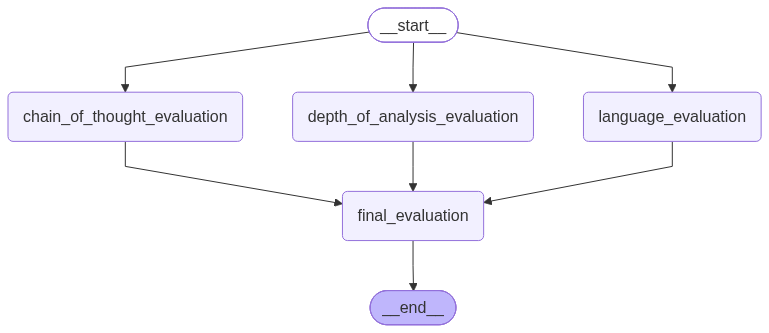

In [ ]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())